# TAE-IA · Module 6 · L02 — Prompting Mastery: Text-to-Image

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L02 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisite** | L01 completed — SD 1.5 weights cached in Drive |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Build structured prompts using the 5-layer anatomy (subject, setting, style, quality, reference)
- [ ] Use negative prompts to reduce specific artifacts
- [ ] Load and compare community fine-tuned models from Hugging Face Hub
- [ ] Save outputs with systematic filenames for reproducible analysis

## Before you start
- L01 completed: SD 1.5 weights should already be cached in `TAE_IA_M6/models` on your Drive
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed. SD 1.5 weights load from cache — no re-download needed if you completed L01.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [2]:
# ================================================================
# Install dependencies for L02
# ================================================================
!pip install diffusers transformers accelerate -q

import diffusers
print(f'diffusers {diffusers.__version__}')

diffusers 0.40.0


## Cell 0b — HuggingFace Login (needed every new Colab session)

> Colab wipes your login state every time you get a fresh runtime, even though your `HF_TOKEN` secret itself stays saved in your account. This cell re-authenticates using that saved secret so the gated SD 1.5 checkpoint below can download. If this is your first time, see **L00 Cell 4** for how to create the token and accept the model license.

In [3]:
# ================================================================
# Ensure HuggingFace login -- needed every new Colab session
# ================================================================
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Already logged in to HuggingFace as: Zanz19


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### Prompt anatomy — the 5 layers

A prompt is not a sentence you describe to a friend — it is a **stack of descriptors** that the CLIP encoder converts into a vector. Each layer adds a different kind of information:

| Layer | What it controls | Example |
|---|---|---|
| **Subject** | What is in the image | `a red fox sitting on a rock` |
| **Setting** | Location, time, atmosphere | `in a snowy forest, winter dawn` |
| **Style** | Artistic medium or movement | `oil painting, impressionist` |
| **Quality** | Technical sharpness and detail | `8k, highly detailed, sharp focus` |
| **Reference** | Artist or aesthetic anchor | `by Ivan Shishkin` |

**Word order matters slightly:** CLIP gives marginally more attention weight to tokens closer to the beginning of the prompt. Put your most important descriptors first.

**Token limit:** CLIP truncates at 77 tokens. A word is roughly 1 token; punctuation and spaces add tokens. Prompts longer than ~60 words risk having the end silently ignored.

### Negative prompts

A negative prompt tells the model what to *move away from* during denoising. It works because Classifier-Free Guidance (CFG) computes:

```
final_output ≈ negative_output + guidance_scale × (positive_output − negative_output)
```

By default, `negative_output` uses an empty string embedding ("unconditioned"). Replacing it with a real negative prompt embedding makes the model actively steer away from those concepts.

Common starting negative prompt:
```
blurry, low quality, deformed, extra limbs, extra fingers, watermark, text, bad anatomy, cropped
```

### Community models

The Hugging Face Hub hosts thousands of fine-tuned SD 1.5 variants. They are loaded with the **exact same code** as the base model — only the model ID changes. The weights are cached to Drive on first download.

### Connection to L01

You already know how to load a pipeline and the effect of `num_inference_steps` and `guidance_scale`. This lesson focuses on the content of the prompt itself — the same pipeline, more controlled inputs.

---

## Part 2 — Lab

### Section 2.1 — Load the pipeline

SD 1.5 loads from Drive cache — should be fast.

In [4]:
# Section 2.1 — Load pipeline and output helper
from diffusers import StableDiffusionPipeline
import torch, os, time
import matplotlib.pyplot as plt

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
print("Pipeline ready.")

# Helper: save image with a systematic filename
OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L02_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_img(img, prompt_id, seed=SEED, steps=25, cfg=7.5):
    fname = f"p{prompt_id:02d}_s{seed}_st{steps}_cfg{cfg:.0f}.png"
    img.save(os.path.join(OUTPUT_DIR, fname))
    return fname

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Pipeline ready.


### Section 2.2 — Prompt structure comparison grid

Same subject, 4 prompts with progressively more layers. Same seed throughout so the only variable is the prompt.

  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 1 done  → p01_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 2 done  → p02_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 3 done  → p03_s42_st25_cfg8.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 4 done  → p04_s42_st25_cfg8.png


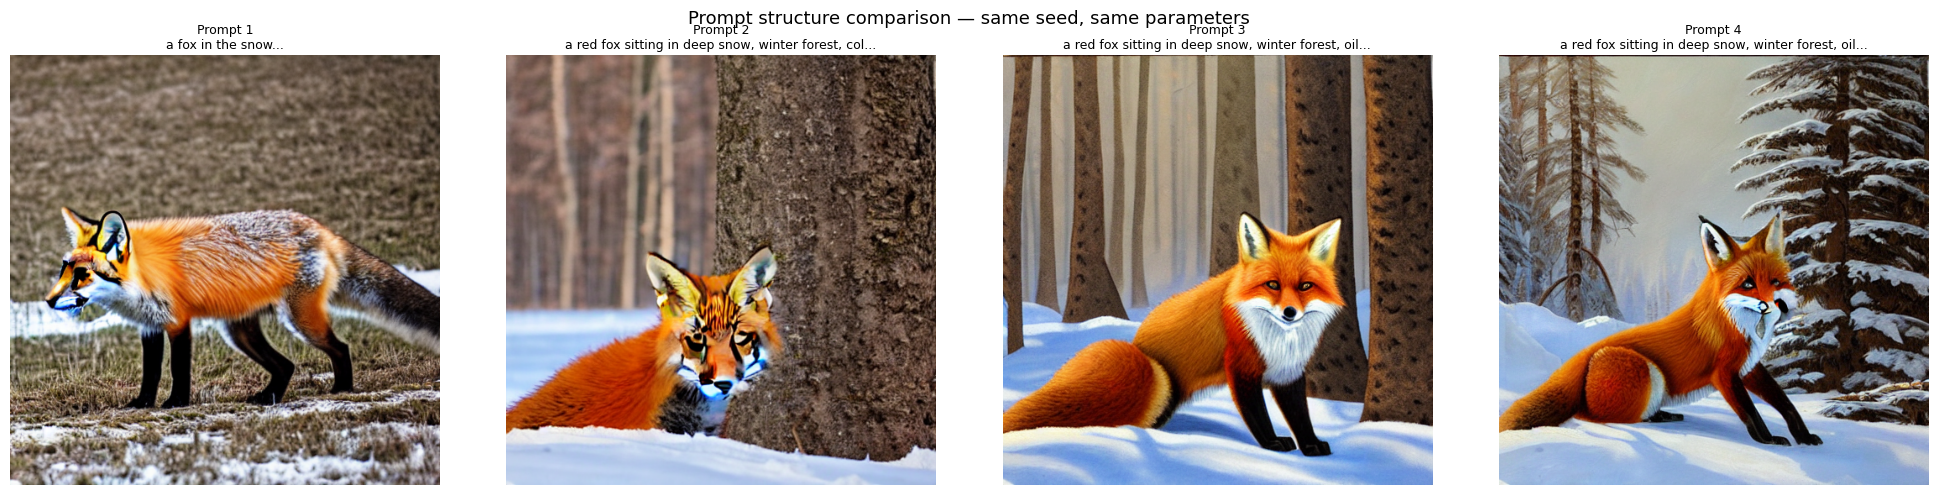

In [5]:
# Section 2.2 — 4-prompt comparison grid
STEPS = 25
CFG   = 7.5

prompts = [
    (1, "a fox in the snow"),
    (2, "a red fox sitting in deep snow, winter forest, cold morning light"),
    (3, "a red fox sitting in deep snow, winter forest, oil painting, detailed fur texture, soft morning light"),
    (4, "a red fox sitting in deep snow, winter forest, oil painting by Ivan Shishkin, "
        "detailed fur texture, soft morning light, artstation trending, 8k resolution"),
]

images = []
for pid, prompt in prompts:
    img = pipe(prompt, num_inference_steps=STEPS, guidance_scale=CFG, generator=gen()).images[0]
    fname = save_img(img, pid)
    images.append((pid, prompt[:50] + "...", img))
    print(f"Prompt {pid} done  → {fname}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (pid, label, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(f"Prompt {pid}\n{label}", fontsize=9, wrap=True)
    ax.axis('off')
plt.suptitle("Prompt structure comparison — same seed, same parameters", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_prompt_structure.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which layer (setting, style, quality, artist) changed the image most noticeably?
- Did adding the artist reference change the composition or just the style?

*Write your observation here:*

- La capa de estilo fue la que mas altera la imagen, de parecer un zorro deforme lo genera mas definido y sin patrones raros
- No modifica mucho la imagen en si, lo que le da es un acabado mas realista al darle una forma mas real y menos animada al zorro, si lo modifica pero ligeramente

### Section 2.3 — Negative prompts

Run the same rich prompt (Prompt 4) with and without a negative prompt. Then progressively expand the negative prompt to target specific artifacts you see.

  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'none' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'basic' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'anatomy' done


  0%|          | 0/25 [00:00<?, ?it/s]

Negative 'extended' done


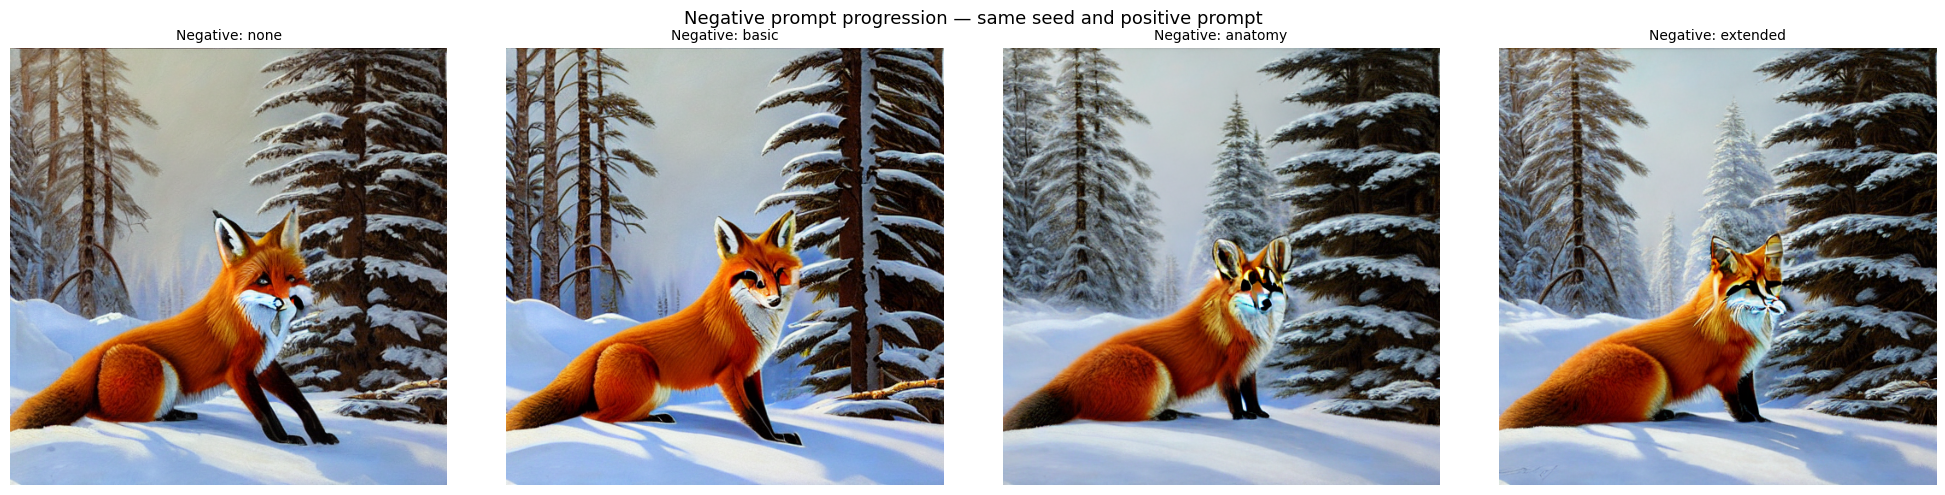

In [7]:
# Section 2.3 — Negative prompt comparison
rich_prompt = ("a red fox sitting in deep snow, winter forest, oil painting by Ivan Shishkin, "
               "detailed fur texture, soft morning light, artstation trending, 8k resolution")

negative_prompts = [
    ("none",     None),
    ("basic",    "blurry, low quality, watermark, text"),
    ("anatomy",  "blurry, low quality, watermark, text, deformed, extra limbs, bad anatomy"),
    ("extended", "blurry, low quality, watermark, text, deformed, extra limbs, bad anatomy, "
                 "poorly drawn, jpeg artifacts, cropped, worst quality, low resolution"),
]

neg_images = []
for label, neg in negative_prompts:
    img = pipe(
        rich_prompt,
        negative_prompt=neg,
        num_inference_steps=STEPS,
        guidance_scale=CFG,
        generator=gen()
    ).images[0]
    neg_images.append((label, img))
    img.save(os.path.join(OUTPUT_DIR, f"neg_{label}.png"))
    print(f"Negative '{label}' done")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, neg_images):
    ax.imshow(img)
    ax.set_title(f"Negative: {label}", fontsize=10)
    ax.axis('off')
plt.suptitle("Negative prompt progression — same seed and positive prompt", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_negative_prompts.png"), dpi=100)
plt.show()

**What do you observe?**  
- Did the negative prompt fix a specific artifact, or did it change the image more broadly?
- Was there a point of diminishing returns (longer negative = not much better)?

*Write your observation here:*

- Empeoro considerablemente la anatomia y colores del zorro pero fortalecio la estructura de los pinos de atras, los hizo mas frondosos
- El unico punto que mejoro el promt extendido fue el fondo lo detallo mucho mas pero eso hizo que se encareciera el zorro el cual es la figura principal

### Section 2.4 — Try a community model

Load DreamShaper (a popular SD 1.5 fine-tune) and run the same prompt. First download is ~2 GB to Drive — subsequent runs are instant.

VRAM freed. Available: 15.6 GB


model_index.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


DreamShaper loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Generated with DreamShaper.


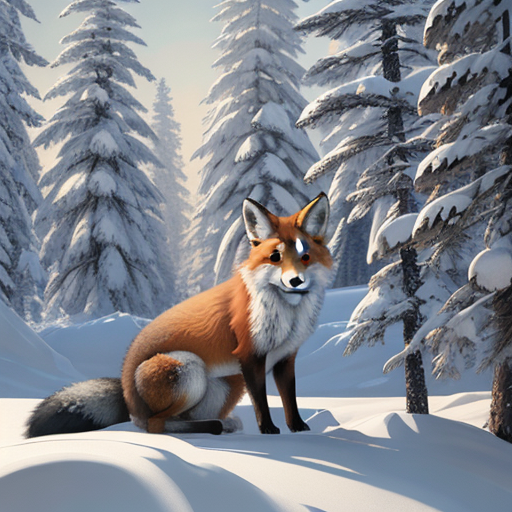

In [8]:
# Section 2.4 — Community model comparison
import gc

# Free SD 1.5 from GPU before loading another model
del pipe
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

pipe_ds = StableDiffusionPipeline.from_pretrained(
    "Lykon/dreamshaper-8",
    torch_dtype=torch.float16
).to("cuda")
print("DreamShaper loaded.")

img_ds = pipe_ds(
    rich_prompt,
    negative_prompt="blurry, low quality, deformed, extra limbs, watermark, text",
    num_inference_steps=STEPS,
    guidance_scale=CFG,
    generator=gen()
).images[0]
img_ds.save(os.path.join(OUTPUT_DIR, "dreamshaper_fox.png"))
print("Generated with DreamShaper.")
img_ds

**What do you observe?**  
- How does DreamShaper's output differ from SD 1.5 on the same prompt and seed?
- What style characteristics are different (color palette, sharpness, composition)?

*Write your observation here:*

- Es mas fiel con la anatomia del zorro pero aun falla en expresiones "comunes" como lo son sus ojos, haciendolo parecer esta expresion "0_o", el fondo si se detalla mas agregando mas nieve a los arboles, mas frondosos lo que si es que las escalas de tamaño y perspectiva se vuelven raras en etse modelo, dandole un tamaño mayor al zorro
- Se nota una mayor iluminacion, parece un retrato al oleo, mas suavidad en los trazos, saturacion en los colores sobre todo en el blanco

---
## Part 3 — Exercises

### Exercise 1 — Your own subject

**Task:** Choose a different subject (not a fox). Build a 4-prompt comparison grid using the same 5-layer structure as Section 2.2. Use the same seed (42) and the same parameters (25 steps, CFG 7.5).

**Expected output:** A 4-image grid with titles showing which layer was added at each step.

**Constraint:** do not use `photorealistic` as your style — pick a painting or illustration style.

VRAM freed. Available: 15.6 GB


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SD 1.5 reloaded.


...

Prompt 2 done → exercise1_p02.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 3 done → exercise1_p03.png


  0%|          | 0/25 [00:00<?, ?it/s]

Prompt 4 done → exercise1_p04.png


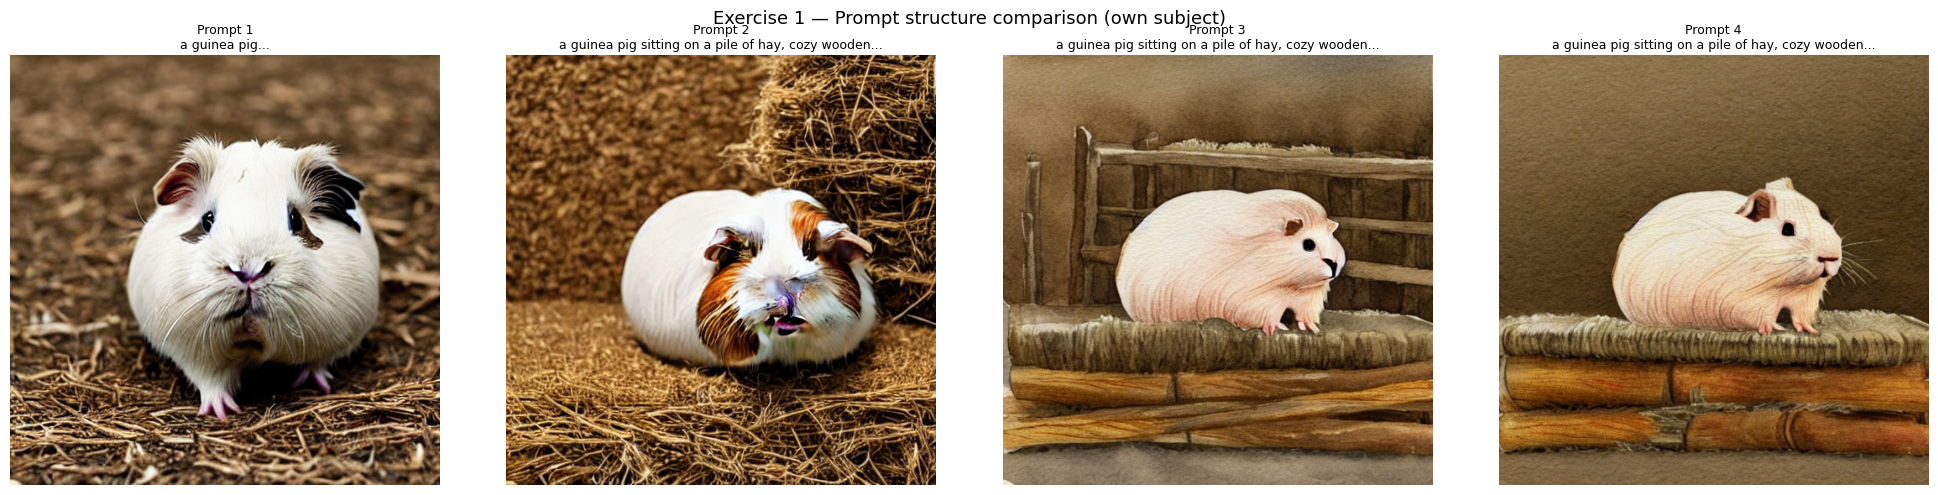

In [9]:
# Exercise 1 -- your code here
# Reload SD 1.5 if you unloaded it in Section 2.4
import gc

# Liberar DreamShaper de la GPU antes de recargar SD 1.5
del pipe_ds
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")
print("SD 1.5 reloaded.")

# Estructura de 5 capas con un subject nuevo (no fox), estilo NO photorealistic
guinea_pig_prompts = [
    (1, "a guinea pig"),
    (2, "a guinea pig sitting on a pile of hay, cozy wooden hutch"),
    (3, "a guinea pig sitting on a pile of hay, cozy wooden hutch, watercolor painting, soft detailed fur"),
    (4, "a guinea pig sitting on a pile of hay, cozy wooden hutch, watercolor painting by Beatrix Potter, "
        "soft detailed fur, artstation trending, 8k resolution"),
]

ex1_images = []
for pid, prompt in guinea_pig_prompts:
    img = pipe(prompt, num_inference_steps=STEPS, guidance_scale=CFG, generator=gen()).images[0]
    fname = f"exercise1_p{pid:02d}.png"
    img.save(os.path.join(OUTPUT_DIR, fname))
    ex1_images.append((pid, prompt[:50] + "...", img))
    print(f"Prompt {pid} done → {fname}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (pid, label, img) in zip(axes, ex1_images):
    ax.imshow(img)
    ax.set_title(f"Prompt {pid}\n{label}", fontsize=9, wrap=True)
    ax.axis('off')
plt.suptitle("Exercise 1 — Prompt structure comparison (own subject)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_grid.png"), dpi=100)
plt.show()

### Exercise 2 — Targeted artifact removal

**Task:** Generate an image that has a visible artifact (extra fingers, distorted face, blurry background, etc.). Then craft a negative prompt that specifically targets *that* artifact and show whether it helped. Use the same seed so the comparison is clean.

**Expected output:** Side-by-side images (before/after negative prompt) with a markdown cell naming the artifact, the negative token(s) you added, and whether they worked.

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

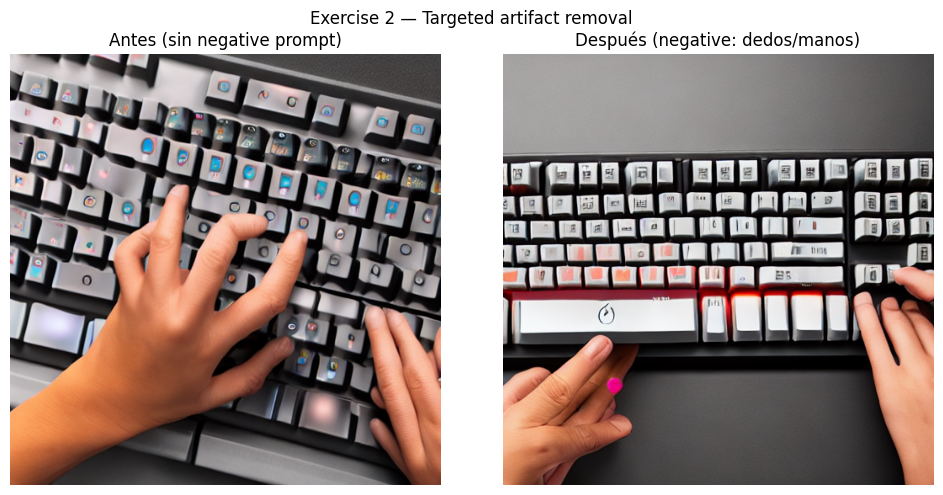

In [10]:
# Exercise 2 -- your code here
artifact_prompt = "closeup of hands typing on a colorful mechanical keyboard, RGB backlit keys, detailed skin"

# Imagen base (sin negative prompt) para identificar el artefacto
img_before = pipe(artifact_prompt, num_inference_steps=STEPS, guidance_scale=CFG, generator=gen()).images[0]
img_before.save(os.path.join(OUTPUT_DIR, "exercise2_before.png"))

# Negative prompt dirigido específicamente al artefacto de dedos/manos
targeted_negative = "extra fingers, missing fingers, fused fingers, malformed hand, deformed hand, extra limbs"

img_after = pipe(
    artifact_prompt,
    negative_prompt=targeted_negative,
    num_inference_steps=STEPS,
    guidance_scale=CFG,
    generator=gen()
).images[0]
img_after.save(os.path.join(OUTPUT_DIR, "exercise2_after.png"))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_before); axes[0].set_title("Antes (sin negative prompt)"); axes[0].axis('off')
axes[1].imshow(img_after); axes[1].set_title("Después (negative: dedos/manos)"); axes[1].axis('off')
plt.suptitle("Exercise 2 — Targeted artifact removal")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_comparison.png"), dpi=100)
plt.show()

*Artifact identified, tokens added, and result (did it work?):*

El artefacto identificado en la imagen base fue un conteo de dedos ambiguo (fusionados) en la mano principal, más un fragmento de una segunda mano cortada en el borde del encuadre; se agregaron los tokens extra fingers, missing fingers, fused fingers, malformed hand, deformed hand, extra limbs, pero el negative prompt no funcionó, en vez de corregir el artefacto original generó uno nuevo y más visible (una mancha/dedo fusionado color rosa fucsia en la punta de un dedo) y además cambió la composición general de la imagen (iluminación del teclado, posición de las manos).

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session — not hypothetical answers.

**4.1 — Which prompt layer (setting, style, quality, or artist reference) produced the most noticeable change in your Section 2.2 grid? Show the two images that best demonstrate it.**

*Write here:*

La capa de style (Prompt 2→3) fue la que produjo el cambio más notorio: resolvió el artefacto/glitch de doble hocico del Prompt 2 y le dio una composición coherente. Las imágenes que mejor lo demuestran son Prompt 2 (deformado) y Prompt 3 (corregido, ya estilizado como pintura).

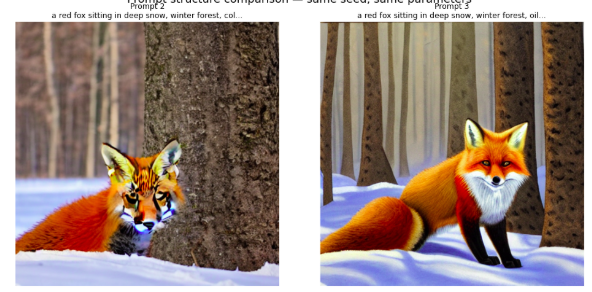


---

**4.2 — In Section 2.3, identify one specific artifact that the negative prompt did NOT fix, even in the extended version. Why do you think the negative prompt failed for that artifact?**

*Write here (be specific about the artifact and your hypothesis):*

El artefacto que no se corrigió, incluso con el negative prompt extendido, fue la distorsión de anatomía/color del zorro en las columnas "anatomy" y "extended" (Section 2.3). Probablemente falló porque tokens como deformed y extra limbs empujan al modelo hacia una región distinta del espacio latente en vez de simplemente evitar el defecto, generando una nueva distorsión en lugar de solucionarla.

---

**4.3 — Compare SD 1.5 and DreamShaper on the same prompt. Name three specific visual differences (not just "it looks better").**

*Write here (e.g., "DreamShaper produced warmer colors", "brushstrokes were more visible in..."):*

(1) SD 1.5 dio un acabado de pintura al óleo con pincelada visible, mientras DreamShaper dio un render nítido tipo 3D/CGI; (2) DreamShaper fue más fiel anatómicamente al zorro real, pero con ojos con brillo especular exagerado; (3) DreamShaper exageró la cantidad de nieve y usó una paleta más fría/blanca, contra el tono cálido/dorado de SD 1.5.

---

**4.4 — What is one limitation of the 5-layer prompt structure you would like to see addressed? What information can you not communicate to the model through a text prompt?**

*Write here:*

Una limitación clara es que el prompt de texto no puede especificar relaciones espaciales o de escala precisas (ej. "el zorro debe estar exactamente a esta distancia de los árboles, en la misma perspectiva"), lo que explica los problemas de encaje/profundidad que viste con DreamShaper — es información geométrica que no se puede comunicar solo con palabras.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 grid saved (`grid_prompt_structure.png`)
- [ ] Section 2.3 negative prompt grid saved (`grid_negative_prompts.png`)
- [ ] Section 2.4 DreamShaper image saved and compared to SD 1.5
- [ ] Exercise 1 — 4-image grid with your own subject
- [ ] Exercise 2 — before/after negative prompt with documented artifact
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L02_output/` on Drive with systematic filenames

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L05

> **Run the cell below only after you have saved this notebook to Drive.**
>
> DreamShaper is only used in L02. Deleting it frees ~4 GB. This is **required** before L05 — ControlNet downloads on top of SD 1.5 and will fill Drive without this cleanup.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [ ]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes DreamShaper (~4 GB) — only used in L02
# ================================================================
import shutil, os, subprocess

# Hardcoded path — works even if setup cell was not re-run this session
_cache = '/content/drive/MyDrive/TAE_IA_M6/models/hub'

to_delete = [
    os.path.join(_cache, 'models--Lykon--dreamshaper-8'),
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6/models'], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L02*  
*Platform: Google Colab (T4 GPU) · Python 3.10*